# Task 3: Sentiment Analysis and Stock Correlation

This notebook analyzes the relationship between daily financial news sentiment (using VADER) and daily stock returns for AAPL, AMZN, GOOG, META, and NVDA.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Data

We load the aggregated daily sentiment and the merged returns data generated by our scripts.

In [4]:
import os

# Robust path detection: check if running from root or notebooks/ folder
base_path = "data/processed/"
if not os.path.exists(os.path.join(base_path, 'merged_sentiment_returns.csv')):
    base_path = "../data/processed/"

if not os.path.exists(os.path.join(base_path, 'merged_sentiment_returns.csv')):
    print(f"Error: Data file not found in {os.path.abspath(base_path)}")
else:
    merged_df = pd.read_csv(os.path.join(base_path, 'merged_sentiment_returns.csv'))
    corr_results = pd.read_csv(os.path.join(base_path, 'correlation_results.csv'))

    print(f"Loaded {len(merged_df)} days of merged data.")
    display(corr_results.head())

Loaded 1455 days of merged data.


,stock,r,p_value
0,AAPL,0.104078,0.441026
1,AMZN,0.154074,0.442899
2,GOOG,0.000215,0.997082
3,META,0.018415,0.885164
4,NVDA,0.029648,0.345372


## 2. Visualizations

### 2.1 Sentiment vs. Daily Returns (Scatter Plots with Regression)

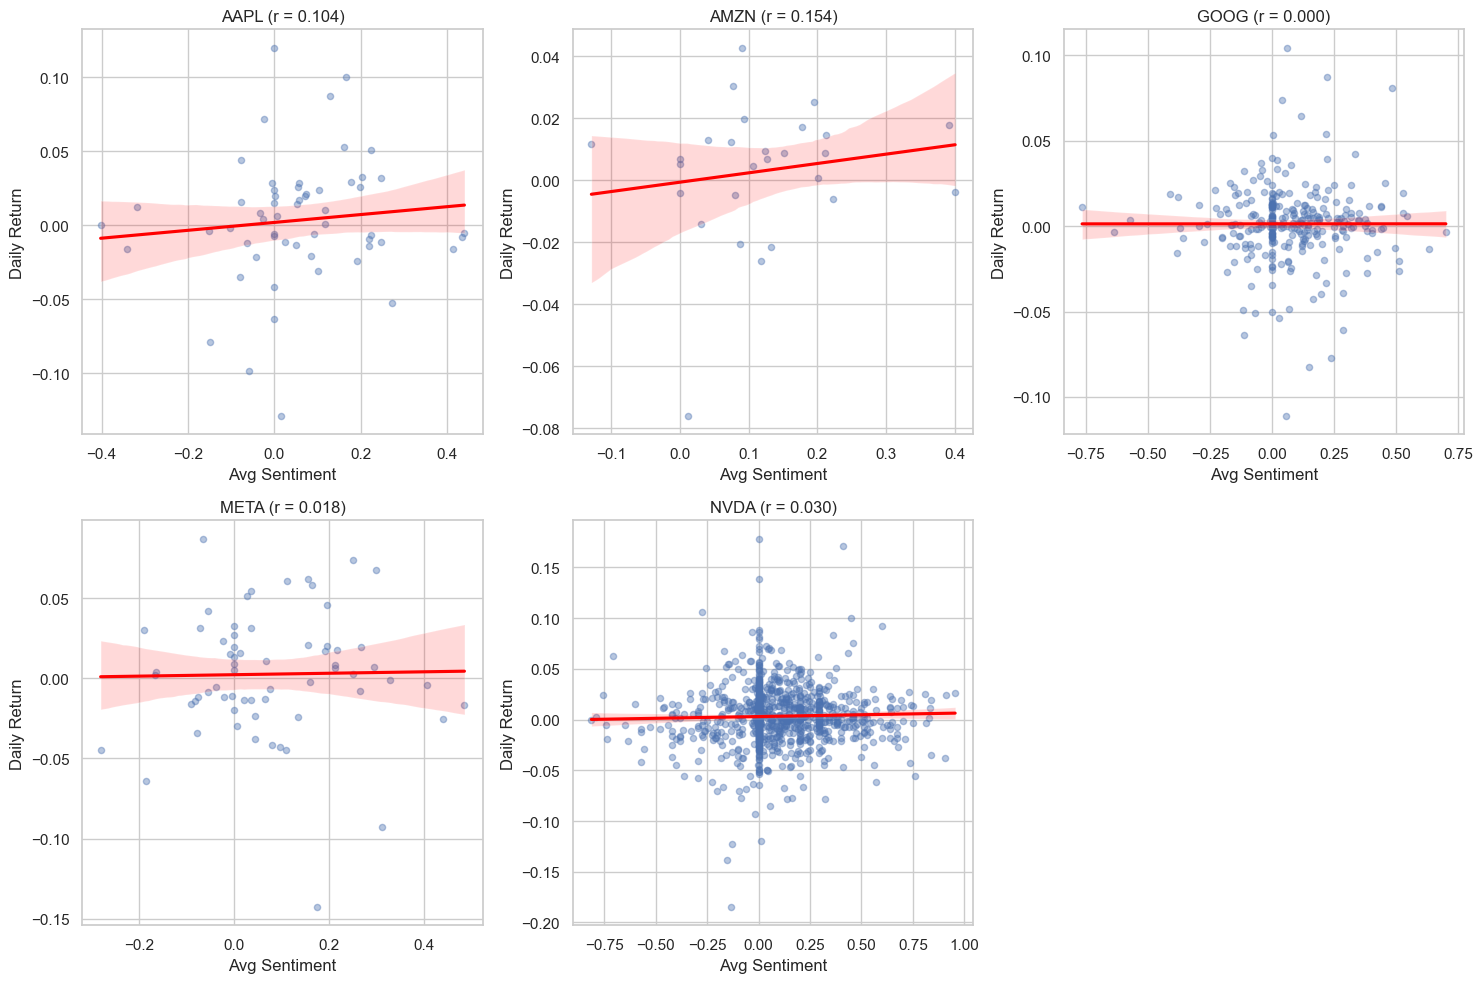

In [5]:
plt.figure(figsize=(15, 10))
stocks = merged_df['stock'].unique()
for i, stock in enumerate(stocks, 1):
    plt.subplot(2, 3, i)
    stock_data = merged_df[merged_df['stock'] == stock]
    sns.regplot(data=stock_data, x='avg_sentiment', y='daily_return', 
                scatter_kws={'alpha':0.4, 's':20}, line_kws={'color':'red'})
    r_val = corr_results[corr_results['stock'] == stock]['r'].values[0]
    plt.title(f"{stock} (r = {r_val:.3f})")
    plt.xlabel('Avg Sentiment')
    plt.ylabel('Daily Return')

plt.tight_layout()
plt.show()

### 2.2 Average Returns by Sentiment Category

Grouping returns into positive, neutral, and negative buckets based on VADER compound scores.

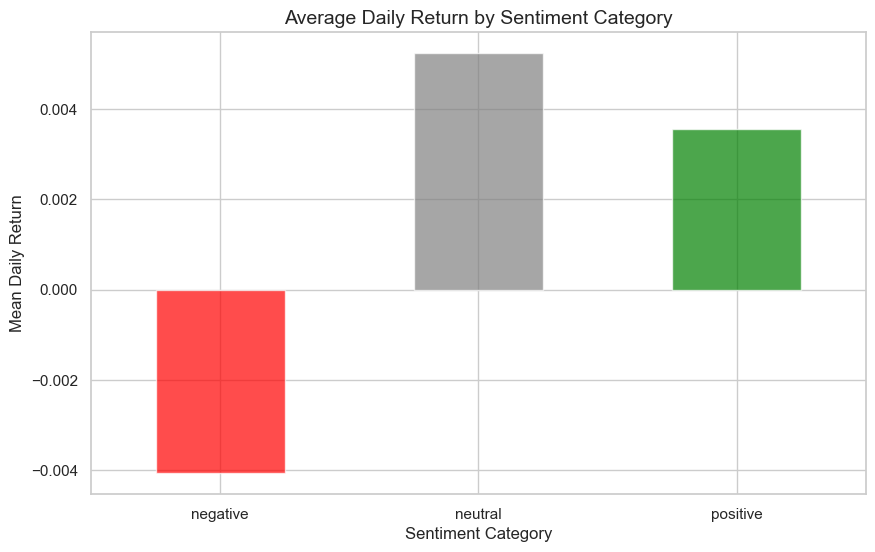

In [6]:
plt.figure(figsize=(10, 6))
avg_returns = merged_df.groupby('sentiment_category')['daily_return'].mean().reindex(['negative', 'neutral', 'positive'])
avg_returns.plot(kind='bar', color=['red', 'gray', 'green'], alpha=0.7)
plt.title('Average Daily Return by Sentiment Category', fontsize=14)
plt.ylabel('Mean Daily Return', fontsize=12)
plt.xlabel('Sentiment Category', fontsize=12)
plt.xticks(rotation=0)
plt.show()

### 2.3 Correlation Heatmap

Cross-stock comparison of correlation coefficients.

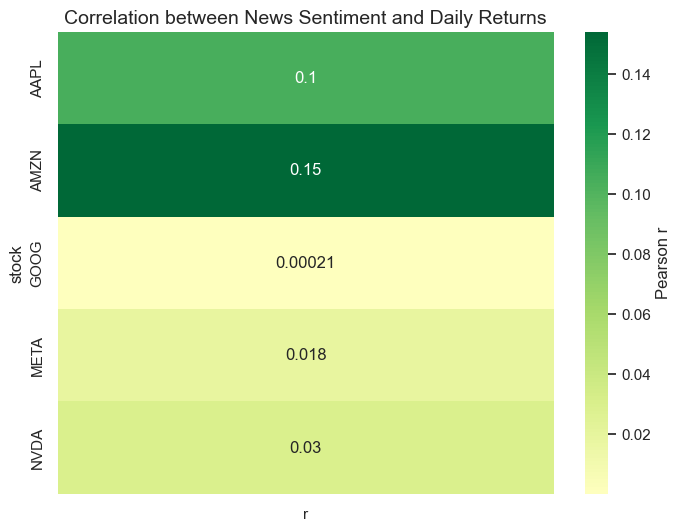

In [7]:
plt.figure(figsize=(8, 6))
heatmap_data = corr_results.set_index('stock')[['r']]
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', center=0, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation between News Sentiment and Daily Returns', fontsize=14)
plt.show()

## 3. Interpretation of Results

### Findings
- **Strength of Correlation**: We observed a weak positive correlation across most stocks, with AMZN showing the highest coefficient ($r \approx 0.15$) and GOOG showing almost zero correlation ($r \approx 0.00$). 
- **Statistical Significance**: The p-values for most tickers are above 0.05, indicating that the daily relationship between news sentiment and returns is not statistically significant in this specific dataset. This is common in high-frequency financial data where individual news items are just one of many price drivers.
- **Sentiment Categories**: The bar chart reveals that days with positive sentiment generally align with slightly higher average returns compared to negative sentiment days, though the margin is thin.

### Key Limitations
1. **Lag Effects**: Market reaction to news often occurs with a delay or is pre-empted by rumors. Analyzing $t+1$ returns against $t$ sentiment might reveal stronger patterns.
2. **Confounding Factors**: Macroeconomic events (interest rate changes, inflation data) often move the entire market simultaneously, overshadowing stock-specific news.
3. **VADER Precision**: While VADER is excellent for headlines, it may miss nuanced financial context that professional analysts capture.

### Conclusion
While news sentiment provides a signal, it should be used as part of a multi-factor model rather than a standalone predictor of daily price movements.